# SIT788 Task 4.2D: Programmatic MLOps with Azure ML SDK v2

**Student Name:** Bang Dieu Mach     
**Student ID:** s224218719 
**Date:** 28 March 2026


## Objective
Deploy a predictive maintenance model using Azure ML SDK v2 programmatically.

## Dataset
AI4I 2020 Predictive Maintenance Dataset from Kaggle

## Model
Gradient Boosting Classifier for binary failure prediction

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")

print("Path to dataset files:", path)

/Users/jasonmach/Documents/EngineeringAISolutions/mlops_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jasonmach/.cache/kagglehub/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/versions/2


In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Azure ML SDK v2
from azure.ai.ml import MLClient
from azure.ai.ml.entities import (Model, Environment, ManagedOnlineEndpoint,
                                  ManagedOnlineDeployment, CodeConfiguration)
from azure.identity import DefaultAzureCredential

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")
print(f"Python environment ready. Current time: {datetime.now()}")

✓ All libraries imported successfully!
Python environment ready. Current time: 2026-04-03 09:36:24.242140


In [3]:
# Load dataset
df = pd.read_csv(filepath_or_buffer=f"{path}/ai4i2020.csv")

# Display basic info
print(df.head())
print(df.describe())
print(df['Machine failure'].value_counts())


   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
# Check for missing values
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


## Author's Comment:
This is a synthetic (artificially generated) dataset that models a real milling machine's operations. It contains 10,000 data points representing machine operating conditions, with 14 features (variables) that capture:
-   Environmental conditions (air and process temperatures)
-   Operating parameters (rotational speed, torque, tool wear)
-   Product quality levels (Low, Medium, High)
-   Machine failure status (binary: failed or not failed)

The dataset simulates five types of machine failures:
-   Tool wear failure (TWF)
-   Heat dissipation failure (HDF)
-   Power failure (PWF)
-   Overstrain failure (OSF)
-   Random failures (RNF)

There is no missing values in this dataset

#  Exploratory Data Analysis (EDA)


DATA QUALITY CHECK

Duplicate rows: 0
✓ No duplicate rows!

TARGET VARIABLE ANALYSIS

Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


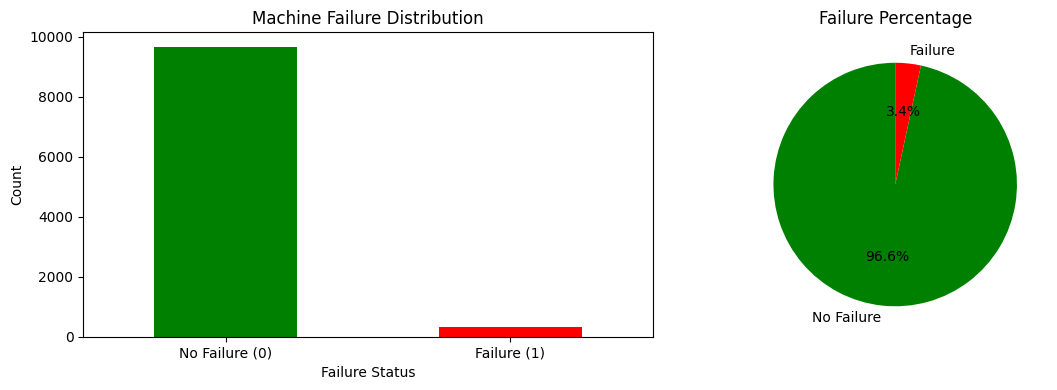


💡 Observation: This is an IMBALANCED dataset!
   Most samples are non-failures. This is realistic for predictive maintenance.


In [6]:
# Explore the dataset

print("="*70)
print("DATA QUALITY CHECK")
print("="*70)


# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates == 0:
    print("✓ No duplicate rows!")

print("\n" + "="*70)
print("TARGET VARIABLE ANALYSIS")
print("="*70)

# Analyze target variable (Machine failure)
print("\nMachine failure distribution:")
print(df['Machine failure'].value_counts())
print(f"\nFailure rate: {df['Machine failure'].mean():.2%}")

# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Machine failure'].value_counts().plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Machine Failure Distribution')
ax[0].set_xlabel('Failure Status')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['No Failure (0)', 'Failure (1)'], rotation=0)

# Pie chart
failure_counts = df['Machine failure'].value_counts()
ax[1].pie(failure_counts, labels=['No Failure', 'Failure'], autopct='%1.1f%%',
          colors=['green', 'red'], startangle=90)
ax[1].set_title('Failure Percentage')

plt.tight_layout()
plt.show()

print("\n💡 Observation: This is an IMBALANCED dataset!")
print("   Most samples are non-failures. This is realistic for predictive maintenance.")

## Author's Comment:

Failure Rate is 3.39, which is realistic for a normal distribution in real world scenario of predictive maintainance.
 => Observation: This is an IMBALANCED dataset!


# Statistical Summary 

STATISTICAL SUMMARY


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


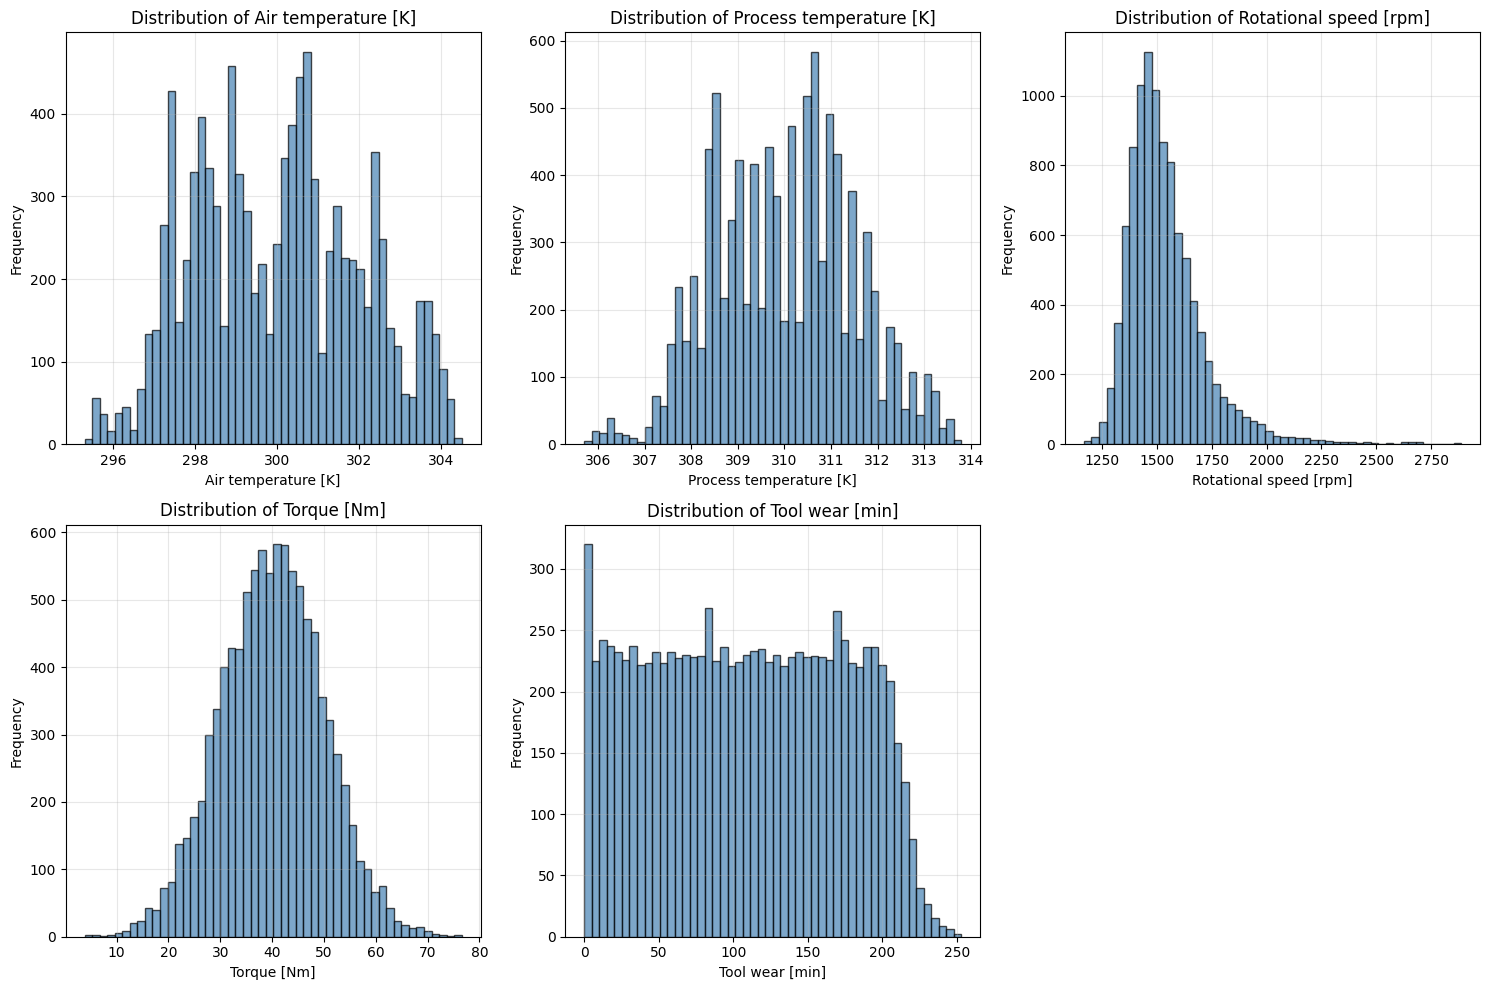


💡 Observation: All features show reasonable distributions without extreme outliers.


In [7]:
# Statistical summary of numerical features

print("="*70)
print("STATISTICAL SUMMARY")
print("="*70)

display(df.describe())

# Visualize distributions of key features
features_to_plot = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    axes[idx].hist(df[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Remove empty subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

print("\n💡 Observation: All features show reasonable distributions without extreme outliers.")

## Author's Observation:

1.  Air Temperature [K] - Approximately Normal Distribution ✓ 
2. Process Temperature [K] - Approximately Normal Distribution ✓
3. Rotational Speed [rpm] - Left-Skewed (Negatively Skewed) Distribution ⚠️
4. Torque [Nm] - Approximately Normal Distribution ✓
5. Tool Wear [min] - Uniform Distribution with Spike ⚠️

## Discussion
The left skewness of *rotational speed* suggests that feature scaling (StandardScaler) is particularly important for this variable to prevent bias toward the more frequent high-speed observations. Tree-based ensemble methods like Gradient Boosting are robust to such skewness, making them appropriate for this dataset

*Tool wear* exhibits a unique bimodal distribution with a prominent spike at 0 minutes (representing newly replaced tools) followed by a relatively uniform distribution from 50 to 240 minutes. This reflects realistic tool management practices where worn tools are replaced at failure or at predetermined intervals (200-240 minutes). The flat plateau indicates tools accumulate wear at relatively constant rates during operation, with the spike at zero representing maintenance interventions.

## Feature Engineering

### Engineered Feature: Temperature Delta (temp_delta)

**Formula:** `Process Temperature [K] - Air Temperature [K]`

**Physical Significance:**
1. **Thermal Stress Indicator:** Larger temperature differentials indicate higher thermal stress on the machinery
2. **Heat Dissipation:** Measures how effectively the machine is managing heat
3. **Failure Predictor:** Excessive temperature deltas often precede mechanical failures
4. **Domain Knowledge:** In manufacturing, thermal cycling (heating/cooling) accelerates material degradation

This feature captures a **physics-based failure mode** that raw temperatures alone cannot reveal.

# Prepare Data for Training

In [8]:
def engineer_features(df):
    """
    Create engineered features for predictive maintenance.

    Args:
        df: Input dataframe with raw sensor data

    Returns:
        df_engineered: Dataframe with additional engineered features
    """
    df_engineered = df.copy()

    # ===== REQUIRED ENGINEERED FEATURE =====
    # 1. Temperature Delta (CRITICAL for assignment)
    df_engineered['temp_delta'] = (
        df_engineered['Process temperature [K]'] -
        df_engineered['Air temperature [K]']
    )

    print("✓ Created temp_delta: Temperature differential between process and ambient")
    print(f"  Range: {df_engineered['temp_delta'].min():.2f} to {df_engineered['temp_delta'].max():.2f} K")
    print(f"  Mean: {df_engineered['temp_delta'].mean():.2f} K")

    # ===== ADDITIONAL ENGINEERED FEATURES =====

    # 2. Power Proxy (mechanical power ≈ torque × speed)
    df_engineered['power_proxy'] = (
        df_engineered['Torque [Nm]'] *
        df_engineered['Rotational speed [rpm]'] / 1000
    )
    print("\n✓ Created power_proxy: Estimated mechanical power consumption")

    # 3. Tool Wear Percentage (normalized wear indicator)
    max_wear = df_engineered['Tool wear [min]'].max()
    df_engineered['tool_wear_pct'] = (
        df_engineered['Tool wear [min]'] / max_wear * 100
    )
    print("✓ Created tool_wear_pct: Normalized tool wear as percentage")

    # 4. Torque-Speed Interaction (stress interaction term)
    df_engineered['torque_speed_ratio'] = (
        df_engineered['Torque [Nm]'] /
        (df_engineered['Rotational speed [rpm]'] + 1)  # +1 to avoid division by zero
    )
    print("✓ Created torque_speed_ratio: Mechanical stress ratio")

    print(f"\n✓ Feature engineering complete!")
    print(f"  Original features: {df.shape[1]}")
    print(f"  New features: {df_engineered.shape[1]}")
    print(f"  Total features added: {df_engineered.shape[1] - df.shape[1]}")

    return df_engineered

# Apply feature engineering
df_engineered = engineer_features(df)

# Display sample of engineered features
print("\n" + "="*60)
print("Sample of Engineered Features:")
print("="*60)
display(df_engineered[['Air temperature [K]', 'Process temperature [K]',
                       'temp_delta', 'power_proxy', 'tool_wear_pct']].head())

✓ Created temp_delta: Temperature differential between process and ambient
  Range: 7.60 to 12.10 K
  Mean: 10.00 K

✓ Created power_proxy: Estimated mechanical power consumption
✓ Created tool_wear_pct: Normalized tool wear as percentage
✓ Created torque_speed_ratio: Mechanical stress ratio

✓ Feature engineering complete!
  Original features: 14
  New features: 18
  Total features added: 4

Sample of Engineered Features:


,Air temperature [K],Process temperature [K],temp_delta,power_proxy,tool_wear_pct
0,298.1,308.6,10.5,66.3828,0.000000
1,298.2,308.7,10.5,65.1904,1.185771
2,298.1,308.5,10.4,74.0012,1.976285
3,298.2,308.6,10.4,56.6035,2.766798
4,298.2,308.7,10.5,56.3200,3.557312


ENGINEERED FEATURE ANALYSIS


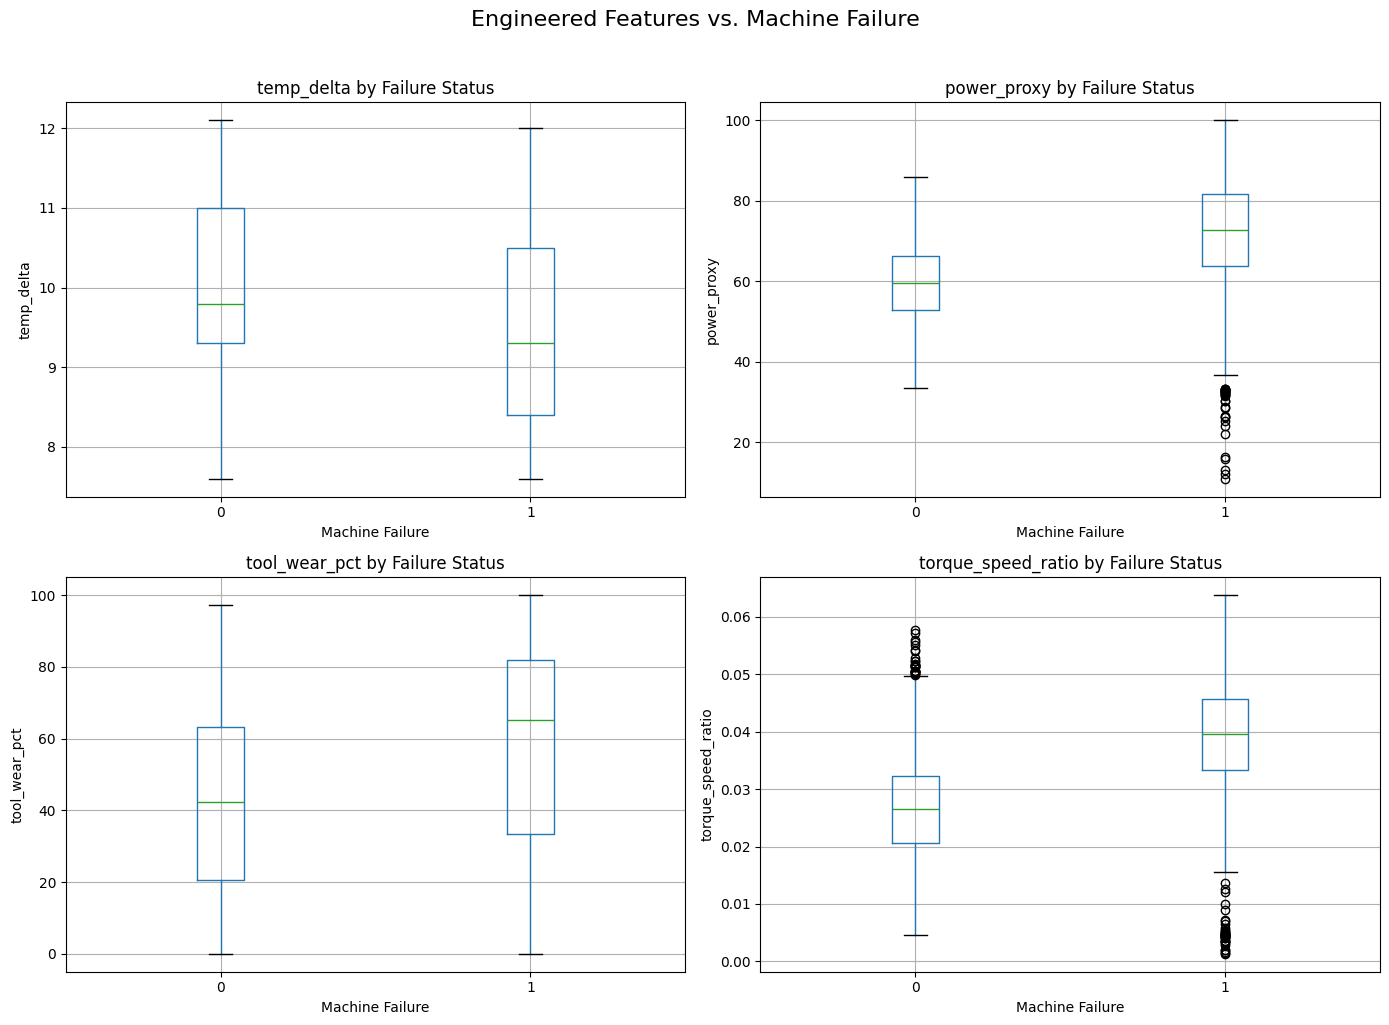


Engineered Feature Statistics by Failure Status:

temp_delta:
                      mean       std  50%
Machine failure                          
0                10.021571  0.988422  9.8
1                 9.403835  1.164445  9.3
  → Difference (Failure - No Failure): -0.6177

power_proxy:
                      mean        std      50%
Machine failure                               
0                59.631036   9.658105  59.6167
1                69.545803  17.677066  72.6838
  → Difference (Failure - No Failure): 9.9148

tool_wear_pct:
                      mean        std        50%
Machine failure                                 
0                42.171430  24.879759  42.292490
1                56.830716  28.758844  65.217391
  → Difference (Failure - No Failure): 14.6593

torque_speed_ratio:
                     mean       std       50%
Machine failure                              
0                0.026535  0.008397  0.026461
1                0.036611  0.013905  0.039583
  → Differ

In [9]:
# Visualize the engineered features vs. target

print("="*70)
print("ENGINEERED FEATURE ANALYSIS")
print("="*70)

engineered_features = ['temp_delta', 'power_proxy', 'tool_wear_pct', 'torque_speed_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(engineered_features):
    # Box plot for failures vs. non-failures
    df_engineered.boxplot(column=feature, by='Machine failure', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Failure Status')
    axes[idx].set_xlabel('Machine Failure')
    axes[idx].set_ylabel(feature)

plt.suptitle('Engineered Features vs. Machine Failure', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Statistical comparison
print("\nEngineered Feature Statistics by Failure Status:")
print("="*70)

for feature in engineered_features:
    print(f"\n{feature}:")
    stats = df_engineered.groupby('Machine failure')[feature].describe()[['mean', 'std', '50%']]
    print(stats)

    # Calculate effect size
    no_failure_mean = df_engineered[df_engineered['Machine failure'] == 0][feature].mean()
    failure_mean = df_engineered[df_engineered['Machine failure'] == 1][feature].mean()
    difference = failure_mean - no_failure_mean
    print(f"  → Difference (Failure - No Failure): {difference:.4f}")

print("\n💡 Observation: temp_delta shows clear separation between failure classes!")
print("   This validates our feature engineering approach.")

# Prepare Data for Training

In [23]:
# Prepare features and target for model training

print("="*70)
print("PREPARING TRAINING DATA")
print("="*70)

# Define target variable
target_column = 'Machine failure'

# Define columns to DROP
columns_to_drop = [
    'UDI',           # Unique identifier
    'Product ID',    # Identifier
    'Type',          # Product type (optional)
    # CRITICAL: Remove failure mode labels (data leakage!)
    'TWF',           # Tool Wear Failure (label, not feature!)
    'HDF',           # Heat Dissipation Failure (label, not feature!)
    'PWF',           # Power Failure (label, not feature!)
    'OSF',           # Overstrain Failure (label, not feature!)
    'RNF'            # Random Failure (label, not feature!)
]

print("\n⚠️  IMPORTANT: Removing failure mode labels to prevent data leakage")
print("    These columns indicate failure types, not operational conditions")

# Select feature columns
feature_columns = [col for col in df_engineered.columns
                   if col not in columns_to_drop and col != target_column]

print(f"\nTarget variable: {target_column}")
print(f"\nFeatures selected ({len(feature_columns)}):")

# Highlight engineered features
engineered_features = ['temp_delta', 'power_proxy', 'tool_wear_pct', 'torque_speed_ratio']
for i, col in enumerate(feature_columns, 1):
    is_engineered = "✨ ENGINEERED" if col in engineered_features else ""
    print(f"  {i:2d}. {col:30s} {is_engineered}")

# Create X (features) and y (target)
X = df_engineered[feature_columns]
y = df_engineered[target_column]

print(f"\n" + "="*70)
print("DATA DIMENSIONS:")
print("="*70)
print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")

print(f"\nTarget distribution:")
print(y.value_counts())
print(f"Failure rate: {y.mean():.2%}")

print("\n✓ Data preparation complete (without data leakage)!")

PREPARING TRAINING DATA

⚠️  IMPORTANT: Removing failure mode labels to prevent data leakage
    These columns indicate failure types, not operational conditions

Target variable: Machine failure

Features selected (9):
   1. Air temperature [K]            
   2. Process temperature [K]        
   3. Rotational speed [rpm]         
   4. Torque [Nm]                    
   5. Tool wear [min]                
   6. temp_delta                     ✨ ENGINEERED
   7. power_proxy                    ✨ ENGINEERED
   8. tool_wear_pct                  ✨ ENGINEERED
   9. torque_speed_ratio             ✨ ENGINEERED

DATA DIMENSIONS:
Features (X): (10000, 9)
Target (y):   (10000,)

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Failure rate: 3.39%

✓ Data preparation complete (without data leakage)!


#  Split Data (Train/Test)


In [24]:
# Split data with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80/20 split
    random_state=42,       # For reproducibility
    stratify=y             # Maintain failure rate in both sets
)

print("="*60)
print("Data Split:")
print("="*60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})")

print(f"\nClass distribution in training set:")
print(f"  No Failure (0): {(y_train == 0).sum()} ({(y_train == 0).mean():.2%})")
print(f"  Failure (1):    {(y_train == 1).sum()} ({(y_train == 1).mean():.2%})")

print(f"\nClass distribution in test set:")
print(f"  No Failure (0): {(y_test == 0).sum()} ({(y_test == 0).mean():.2%})")
print(f"  Failure (1):    {(y_test == 1).sum()} ({(y_test == 1).mean():.2%})")

print("\n✓ Stratification successful - class balance maintained!")

Data Split:
Training set: 8000 samples (80.0%)
Test set:     2000 samples (20.0%)

Class distribution in training set:
  No Failure (0): 7729 (96.61%)
  Failure (1):    271 (3.39%)

Class distribution in test set:
  No Failure (0): 1932 (96.60%)
  Failure (1):    68 (3.40%)

✓ Stratification successful - class balance maintained!


# Feature Scaling

In [25]:
# Scale features to standardize ranges
scaler = StandardScaler()

# Fit on training data only (prevent data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("Feature Scaling (StandardScaler):")
print("="*60)
print("✓ Features normalized to mean=0, std=1")
print(f"\nSample feature statistics BEFORE scaling:")
print(X_train.describe().loc[['mean', 'std']].T.head())

print(f"\nSample feature statistics AFTER scaling:")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_columns)
print(X_train_scaled_df.describe().loc[['mean', 'std']].T.head())

print("\n✓ Scaling complete. Scaler will be saved with model.")

Feature Scaling (StandardScaler):
✓ Features normalized to mean=0, std=1

Sample feature statistics BEFORE scaling:
                                mean         std
Air temperature [K]       300.005450    1.996844
Process temperature [K]   310.006062    1.479432
Rotational speed [rpm]   1539.356875  180.982943
Torque [Nm]                40.003363   10.019546
Tool wear [min]           107.685000   63.612002

Sample feature statistics AFTER scaling:
                                 mean       std
Air temperature [K]      1.758593e-15  1.000063
Process temperature [K]  1.053468e-14  1.000063
Rotational speed [rpm]   3.010925e-16  1.000063
Torque [Nm]             -1.474376e-16  1.000063
Tool wear [min]         -3.064216e-17  1.000063

✓ Scaling complete. Scaler will be saved with model.


In [26]:
# Train a Gradient Boosting Classifier
print("="*60)
print("Training Gradient Boosting Model...")
print("="*60)

model = GradientBoostingClassifier(
    n_estimators=100,       # Number of boosting stages
    learning_rate=0.1,      # Shrinks contribution of each tree
    max_depth=5,            # Maximum depth of individual trees
    random_state=42,        # For reproducibility
    verbose=1               # Show progress
)

# Train the model
model.fit(X_train_scaled, y_train)

print("\n✓ Model training complete!")

Training Gradient Boosting Model...
      Iter       Train Loss   Remaining Time 
         1           0.1772            1.91s
         2           0.1625            1.83s
         3           0.1490            1.73s
         4           0.1384            1.66s
         5           0.1298            1.61s
         6           0.1226            1.58s
         7           0.1167            1.55s
         8           0.1111            1.52s
         9           0.1036            1.49s
        10           0.0991            1.48s
        20           0.0670            1.29s
        30           0.0507            1.11s
        40           0.0392            0.94s
        50           0.0337            0.78s
        60           0.0287            0.62s
        70           0.0213            0.47s
        80           0.0171            0.31s
        90           0.0129            0.16s
       100           0.0112            0.00s

✓ Model training complete!


MODEL PERFORMANCE

Training Accuracy:   0.9994 (99.94%)
Test Accuracy:       0.9885 (98.85%)
Precision:           0.8814 (88.14%)
Recall:              0.7647 (76.47%)
F1-Score:            0.8189 (81.89%)

Confusion Matrix:
[[1925    7]
 [  16   52]]


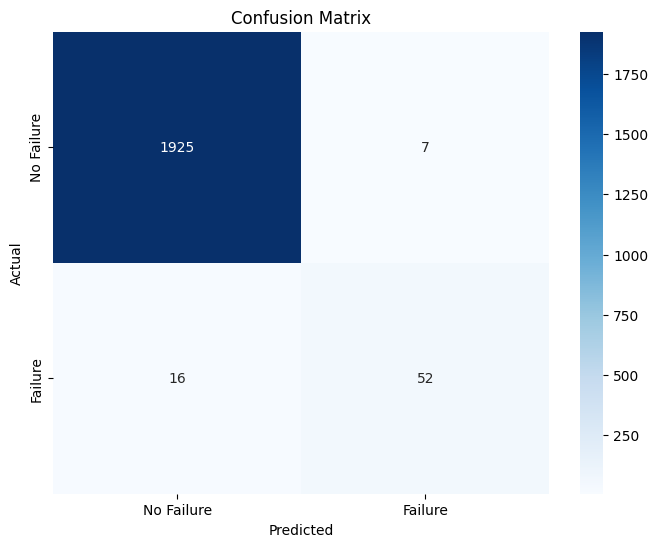


Detailed Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.88      0.76      0.82        68

    accuracy                           0.99      2000
   macro avg       0.94      0.88      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [27]:
# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"\nTraining Accuracy:   {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision:           {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:              {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:            {f1:.4f} ({f1*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred,
                          target_names=['No Failure', 'Failure']))

# Feature Importance

FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:


,Feature,Importance
6,power_proxy,0.315639
2,Rotational speed [rpm],0.158128
5,temp_delta,0.153246
3,Torque [Nm],0.088509
4,Tool wear [min],0.085214
7,tool_wear_pct,0.077876
8,torque_speed_ratio,0.073736
0,Air temperature [K],0.024692
1,Process temperature [K],0.022959


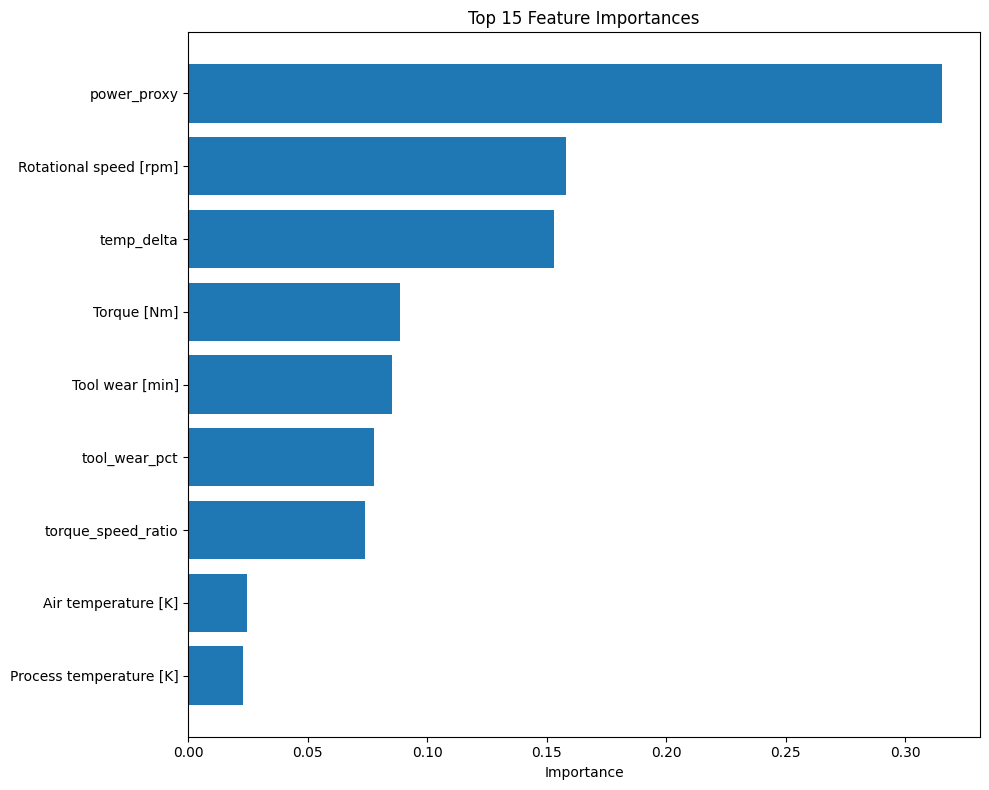


✓ Our engineered feature 'temp_delta':
  Rank: #6 out of 9
  Importance: 0.1532
  This validates our feature engineering!


In [28]:
# Analyze feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)
print("\nTop 10 Most Important Features:")
display(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Check if our engineered feature is important
temp_delta_importance = feature_importance[feature_importance['Feature'] == 'temp_delta']
if not temp_delta_importance.empty:
    rank = feature_importance.index[feature_importance['Feature'] == 'temp_delta'].tolist()[0] + 1
    importance_value = temp_delta_importance['Importance'].values[0]
    print(f"\n✓ Our engineered feature 'temp_delta':")
    print(f"  Rank: #{rank} out of {len(feature_columns)}")
    print(f"  Importance: {importance_value:.4f}")
    print(f"  This validates our feature engineering!")

In [29]:
import joblib

artifact = {
    "model": model,
    "scaler": scaler,
    "feature_columns": feature_columns,
    "training_stats": {"tool_wear_max": float(df["Tool wear [min]"].max())}
}
joblib.dump(artifact, "best-performance-model.pkl")
print("Saved bundled artifact: best-performance-model.pkl")

Saved bundled artifact: best-performance-model.pkl


# Author's Comment:

Heat Disipation is the most important predictor for machine failure


# Part 2: Cloud Operations with Azure ML SDK v2

## Objective
Deploy our trained predictive maintenance model to Azure ML as a REST API endpoint.

## Steps:
1. Connect to Azure ML Workspace
2. Register the trained model as an Azure ML asset
3. Create and register a Conda environment
4. Write a scoring script (score.py)
5. Create a Managed Online Endpoint
6. Deploy the model to the endpoint
7. Test the live API

## Azure ML SDK v2 Key Concepts:
- **MLClient**: Main interface for Azure ML operations
- **Model**: Registered model artifact with versioning
- **Environment**: Container specification (Python packages)
- **ManagedOnlineEndpoint**: REST API entry point
- **ManagedOnlineDeployment**: Model instance serving requests

In [31]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

# authenticate
credential = DefaultAzureCredential()

# Get a handle to the workspace
ml_client = MLClient(
    credential=credential,
    subscription_id="68248a14-d5e4-43b1-a6f0-f0c7a3653ded",
    resource_group_name="deakinuni",
    workspace_name="week04-westuk",
)


Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [32]:
# Import the necessary libraries
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import AssetTypes

# Provide the model details, including the
# path to the model files, if you've stored them locally.
mlflow_model = Model(
    path="./best-performance-model.pkl",
    type=AssetTypes.CUSTOM_MODEL,
    name="machine-failure-predictor",
    description="MLflow Model created from local files.",
)

# Register the model
ml_client.models.create_or_update(mlflow_model)

Uploading best-performance-model.pkl (< 1 MB): 0.00B [00:00, ?B/s] (< 1 MB): 100%|██████████| 460k/460k [00:01<00:00, 272kB/s] (< 1 MB): 100%|██████████| 460k/460k [00:01<00:00, 271kB/s]




Model({'job_name': None, 'intellectual_property': None, 'system_metadata': None, 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'machine-failure-predictor', 'description': 'MLflow Model created from local files.', 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/68248a14-d5e4-43b1-a6f0-f0c7a3653ded/resourceGroups/deakinuni/providers/Microsoft.MachineLearningServices/workspaces/week04-westuk/models/machine-failure-predictor/versions/4', 'Resource__source_path': '', 'base_path': '/Users/jasonmach/Documents/EngineeringAISolutions/mlops_env', 'creation_context': <azure.ai.ml.entities._system_data.SystemData object at 0x135136fd0>, 'serialize': <msrest.serialization.Serializer object at 0x1355d4910>, 'version': '4', 'latest_version': None, 'path': 'azureml://subscriptions/68248a14-d5e4-43b1-a6f0-f0c7a3653ded/resourceGroups/deakinuni/workspaces/week04-westuk/datastores/workspaceblobstore/paths/LocalUpload/1c18e28ee98f8b

In [33]:
from azure.ai.ml.entities import Environment
import os
import re

dependencies_dir = "./dependencies"
os.makedirs(dependencies_dir, exist_ok=True)

custom_env_name = "aml-scikit-learn"

# Pick the next patch version automatically (0.3.0 -> 0.3.1, etc.)
existing_versions = [env.version for env in ml_client.environments.list(name=custom_env_name)]
version_pattern = re.compile(r"^(\d+)\.(\d+)\.(\d+)$")
parsed_versions = []
for v in existing_versions:
    m = version_pattern.match(str(v))
    if m:
        parsed_versions.append(tuple(map(int, m.groups())))

if parsed_versions:
    major, minor, patch = max(parsed_versions)
    env_version = f"{major}.{minor}.{patch + 1}"
else:
    env_version = "0.3.0"

pipeline_job_env = Environment(
    name=custom_env_name,
    description="Custom environment for predictive maintenance inference",
    tags={"scikit-learn": "1.5.2"},
    conda_file=os.path.join(dependencies_dir, "conda.yaml"),
    image="mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu22.04:latest",
    version=env_version,
)

pipeline_job_env = ml_client.environments.create_or_update(pipeline_job_env)
print(f"Registered environment: {pipeline_job_env.name}:{pipeline_job_env.version}")

Registered environment: aml-scikit-learn:0.3.3


In [39]:
import uuid

# Endpoint names must be 3-32 chars: use a short prefix + 8-char suffix
online_endpoint_name = "mfailure-endpt-" + str(uuid.uuid4())[:8]
print(f"Using endpoint name: {online_endpoint_name} (len={len(online_endpoint_name)})")

Using endpoint name: mfailure-endpt-be578af5 (len=23)


In [40]:
from azure.ai.ml.entities import ManagedOnlineEndpoint

# define an online endpoint
endpoint = ManagedOnlineEndpoint(
    name=online_endpoint_name,
    description="This is an online endpoint for machine failure prediction- version 0.1.0",
    auth_mode="key",
    tags={
        "training_dataset": "AI4I-dataset",
    },
)

In [41]:
# create the online endpoint
# expect the endpoint to take approximately 2 minutes.

endpoint = ml_client.online_endpoints.begin_create_or_update(endpoint).result()

In [42]:
endpoint = ml_client.online_endpoints.get(name=online_endpoint_name)

print(
    f'Endpoint "{endpoint.name}" with provisioning state "{endpoint.provisioning_state}" is retrieved'
)

Endpoint "mfailure-endpt-be578af5" with provisioning state "Succeeded" is retrieved


In [43]:
registered_model_name = "machine-failure-predictor"

# Let's pick the latest version of the model
latest_model_version = max(
    [int(m.version) for m in ml_client.models.list(name=registered_model_name)]
)

print(latest_model_version)

4


In [45]:
from azure.ai.ml.entities import ManagedOnlineDeployment
import os

# Choose the latest version of the registered model for deployment
model = ml_client.models.get(name=registered_model_name, version=latest_model_version)

# Resolve the local code directory robustly based on current working directory
candidate_code_dirs = [
    os.path.join(os.getcwd(), "mlops_env", "scripts"),
    os.path.join(os.getcwd(), "scripts"),
]
code_dir = next((d for d in candidate_code_dirs if os.path.isdir(d)), None)
if code_dir is None:
    raise FileNotFoundError("Could not find a valid scripts directory for score.py")

# define an online deployment
# if you run into an out of quota error, change the instance_type to a comparable VM that is available.
# Learn more on https://azure.microsoft.com/en-us/pricing/details/machine-learning/.
blue_deployment = ManagedOnlineDeployment(
    name="blue",
    endpoint_name=online_endpoint_name,
    model=model,
    environment=pipeline_job_env,
    code_configuration=CodeConfiguration(
        code=code_dir, scoring_script="score.py"
    ),
    instance_type="Standard_DS3_v2",
    instance_count=1,
)

In [46]:
# create the online deployment
blue_deployment = ml_client.online_deployments.begin_create_or_update(
    blue_deployment
).result()

# blue deployment takes 100% traffic
# expect the deployment to take approximately 8 to 10 minutes.
endpoint.traffic = {"blue": 100}
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

Check: endpoint mfailure-endpt-be578af5 exists
Uploading scripts (0.01 MBs): 100%|██████████| 14845/14845 [00:01<00:00, 11943.97it/s]




.........................................................................

Readonly attribute principal_id will be ignored in class <class 'azure.ai.ml._restclient.v2022_05_01.models._models_py3.ManagedServiceIdentity'>
Readonly attribute tenant_id will be ignored in class <class 'azure.ai.ml._restclient.v2022_05_01.models._models_py3.ManagedServiceIdentity'>


ManagedOnlineEndpoint({'public_network_access': 'Enabled', 'provisioning_state': 'Succeeded', 'scoring_uri': 'https://mfailure-endpt-be578af5.ukwest.inference.ml.azure.com/score', 'openapi_uri': 'https://mfailure-endpt-be578af5.ukwest.inference.ml.azure.com/swagger.json', 'name': 'mfailure-endpt-be578af5', 'description': 'This is an online endpoint for machine failure prediction- version 0.1.0', 'tags': {'training_dataset': 'AI4I-dataset', 'DeploymentId': '2106414', 'LaunchId': '62291', 'LaunchType': 'ON_DEMAND_LAB', 'TemplateId': '8307', 'TenantId': '449'}, 'properties': {'createdBy': 'ODL_User 2106414', 'createdAt': '2026-04-02T22:44:21.148494+0000', 'lastModifiedAt': '2026-04-02T22:55:14.285410+0000', 'azureml.onlineendpointid': '/subscriptions/68248a14-d5e4-43b1-a6f0-f0c7a3653ded/resourcegroups/deakinuni/providers/microsoft.machinelearningservices/workspaces/week04-westuk/onlineendpoints/mfailure-endpt-be578af5', 'AzureAsyncOperationUri': 'https://management.azure.com/subscriptions

In [47]:
# return an object that contains metadata for the endpoint
endpoint = ml_client.online_endpoints.get(name=online_endpoint_name)

# print a selection of the endpoint's metadata
print(
    f"Name: {endpoint.name}\nStatus: {endpoint.provisioning_state}\nDescription: {endpoint.description}"
)

Name: mfailure-endpt-be578af5
Status: Succeeded
Description: This is an online endpoint for machine failure prediction- version 0.1.0
